In [1]:
from pathlib import Path
import types
import dill


# ============================================================
# LOCALISATION AUTOMATIQUE DU PROJET
# ============================================================

CURRENT_DIR = Path.cwd().resolve()

candidats = [
    CURRENT_DIR,
    CURRENT_DIR / "Script_intermediaire",
    Path.home() / "Downloads" / "Projet 4" / "Script_intermediaire",
]

# Ajout des dossiers parents et de leurs éventuels sous-dossiers
for parent in CURRENT_DIR.parents:
    candidats.append(parent)

    candidats.append(parent / "Script_intermediaire")


SCRIPT_DIR = next(
    (
        chemin
        for chemin in candidats
        if chemin.is_dir()
        and chemin.name == "Script_intermediaire"
    ),
    None,
)


if SCRIPT_DIR is None:
    raise FileNotFoundError(
        "Impossible de localiser le dossier 'Script_intermediaire'.\n"
        f"Dossier courant détecté : {CURRENT_DIR}"
    )


SESSION_DIR = SCRIPT_DIR / "outputs"
SESSION_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# OBJETS TECHNIQUES À NE PAS SAUVEGARDER
# ============================================================

NOMS_TECHNIQUES = {
    "In",
    "Out",
    "exit",
    "quit",
    "get_ipython",
    "open",
    "CURRENT_DIR",
    "SCRIPT_DIR",
    "SESSION_DIR",
    "NOMS_TECHNIQUES",
    "candidats",
    "parent",
    "chemin",
    "sauvegarder_session",
    "charger_session",
    "objets_restaures",
}


# ============================================================
# SAUVEGARDE AUTOMATIQUE
# ============================================================

def sauvegarder_session(etape):
    """
    Sauvegarde automatiquement tous les objets utilisateur
    sérialisables présents dans le notebook.

    Les modules, objets internes de Jupyter/VS Code et objets
    non sérialisables sont ignorés.
    """

    chemin_final = SESSION_DIR / f"session_etape{etape}.pkl"
    chemin_temporaire = SESSION_DIR / f"session_etape{etape}.tmp"

    objets_serialises = {}
    objets_ignores = {}

    for nom, objet in list(globals().items()):

        # Objets internes ou privés
        if nom.startswith("_"):
            continue

        # Infrastructure de sauvegarde
        if nom in NOMS_TECHNIQUES:
            continue

        # Objets techniques injectés par Data Wrangler
        if "DW_OUTPUT_FORMATTER" in nom:
            continue

        # Les modules seront réimportés normalement
        if isinstance(objet, types.ModuleType):
            continue

        try:
            # Chaque objet est sérialisé séparément.
            # Un objet défectueux ne bloque donc pas tous les autres.
            objets_serialises[nom] = dill.dumps(
                objet,
                recurse=True
            )

        except Exception as erreur:
            objets_ignores[nom] = (
                f"{type(erreur).__name__}: {erreur}"
            )

    contenu_session = {
        "version": 1,
        "etape": etape,
        "objets": objets_serialises,
    }

    # Écriture atomique : on écrit d'abord dans un fichier temporaire
    with open(chemin_temporaire, "wb") as fichier:
        dill.dump(contenu_session, fichier)

    chemin_temporaire.replace(chemin_final)

    print("=" * 65)
    print(f"Session de l'étape {etape} enregistrée")
    print(f"Fichier : {chemin_final}")
    print(f"Objets sauvegardés : {len(objets_serialises)}")
    print(f"Objets ignorés : {len(objets_ignores)}")

    if objets_ignores:
        print("\nObjets non sérialisables ignorés :")

        for nom, erreur in objets_ignores.items():
            print(f" - {nom} → {erreur}")

    print("=" * 65)

    return chemin_final


# ============================================================
# CHARGEMENT AUTOMATIQUE
# ============================================================

def charger_session(etape):
    """
    Recharge automatiquement tous les objets enregistrés
    à l'étape demandée, avec leurs noms d'origine.
    """

    chemin_session = SESSION_DIR / f"session_etape{etape}.pkl"

    if not chemin_session.exists():
        raise FileNotFoundError(
            f"Session introuvable : {chemin_session}\n"
            f"Exécute d'abord entièrement le notebook de l'étape {etape}."
        )

    with open(chemin_session, "rb") as fichier:
        contenu_session = dill.load(fichier)

    objets_serialises = contenu_session["objets"]

    objets_restaures = {}
    objets_non_restaures = {}

    for nom, objet_serialise in objets_serialises.items():

        try:
            objets_restaures[nom] = dill.loads(
                objet_serialise
            )

        except Exception as erreur:
            objets_non_restaures[nom] = (
                f"{type(erreur).__name__}: {erreur}"
            )

    globals().update(objets_restaures)

    print("=" * 65)
    print(f"Session de l'étape {etape} chargée")
    print(f"Fichier : {chemin_session}")
    print(f"Objets restaurés : {len(objets_restaures)}")
    print(f"Objets non restaurés : {len(objets_non_restaures)}")

    if objets_non_restaures:
        print("\nObjets impossibles à restaurer :")

        for nom, erreur in objets_non_restaures.items():
            print(f" - {nom} → {erreur}")

    print("=" * 65)

    return objets_restaures


print("Infrastructure de session initialisée")
print("Dossier des notebooks :", SCRIPT_DIR)
print("Dossier des sessions :", SESSION_DIR)

Infrastructure de session initialisée
Dossier des notebooks : C:\Projets\Projet4\Script_intermediaire
Dossier des sessions : C:\Projets\Projet4\Script_intermediaire\outputs


In [2]:
#Librairy


from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)


from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score



import imblearn

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, f1_score





In [3]:
objets_restaures = charger_session(4)

Session de l'étape 4 chargée
Fichier : C:\Projets\Projet4\Script_intermediaire\outputs\session_etape4.pkl
Objets restaurés : 217
Objets non restaurés : 0


# Etape 5 : Optimisation et interprétation du comportement du modèle

4 phases :

- Phase A — Fine-tuning : trouver les meilleurs hyperparamètres du XGBoost

- Phase B — Feature importance globale (3 méthodes à comparer) :
            1. Feature importance native de l'arbre
            2. Permutation Importance (sklearn)
            3. SHAP Beeswarm (TreeExplainer)
- Phase C — SHAP Scatter plot    : comprendre le SENS des valeurs de Shapley
- Phase D — Feature importance locale


Actuellement nous avons :

-  Une cible retenue : a_quitte_l_entreprise (0/1)
- Un modèle XGBoost avec scale_pos_weight pour gérer le déséquilibre
- Un seuil de décision optimisé à 0.088 (choix métier, priorité au Recall classe 1)
- Un dataset X2_train, X2_test, y2_train, y2_test




## Phase A : Le fine tuning


Le fine-tuning définie une grille de valeurs pour les hyperparam!tres qui comptent le plus pour un XGBoost (max_depth, n_estimators, learning_rate, min_child_weight, subsample, etc.). Il utilise uen recheceh automatique (GridSearchCV) qui va tester ces combinaisons avec de la validation croisée (pas seulement un seul split unique) pour réviter de sur-optimiser sur le jeu de test. Il nécessite tout de même de faire le bon choix de méthode de score à optimiser (ici pas l'accuracy, mais le Recall) ou un score composite. Si on base la GridSearch sur la maximisation du Recall il y a des chances que les hyperparamètres obtenus maximise effectivement le Recall mais prédisent dans le même que tout le monde part (donc affaiblissement excessif de la précision). Il n"cessite encore une fois un arbitrage entre les coûts et les gains de chaque stratégies de modèles retenues. Une solutione st de choisir : **scoring='average_precision'** (aire sous la courbe précision-rappel).

scoring='average_precision' permet de mesurer le compromis entre le Recall/Precision en une seule valeur

In [4]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "max_depth": [3, 4, 5, 6],
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_base = XGBClassifier(
    scale_pos_weight=ratio2,
    random_state=42,
    eval_metric="logloss",
)

grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    scoring='average_precision',
    cv=cv_strategy,
    return_train_score=True,   # pour comparer train et test
    n_jobs=-1,
)


grid_search.fit(X2_train, y2_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 0.85, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,objective,'binary:logistic'


972 combinaison x 5 folds


| Hyperparamètre | Valeur retenue |
|---|---|
| `learning_rate` | 0.05 |
| `max_depth` | 4 |
| `min_child_weight` | 5 |
| `n_estimators` | 300 |
| `colsample_bytree` | 0.7 |




In [5]:
print("Meilleurs hyperparamètres :", grid_search.best_params_)
print("Meilleur score CV (average_precision) :", grid_search.best_score_)

best_xgb = grid_search.best_estimator_

Meilleurs hyperparamètres : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.7}
Meilleur score CV (average_precision) : 0.628815427877042


### Visualasition GreadSearch

Tracer le score en fonction d'un seul hylerparamètre (Max_depth qui contrôle l'overfitting) en moyennant sur toutes les aitres combinaisons

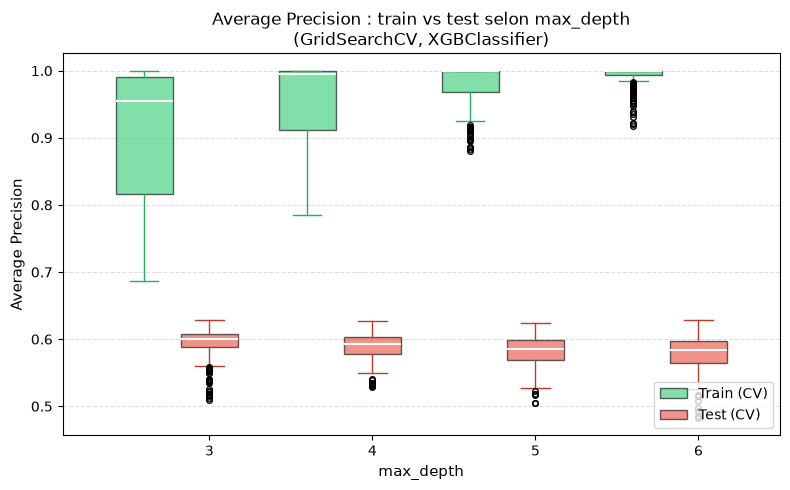

In [6]:
results = grid_search.cv_results_
df_results = pd.DataFrame({
    'max_depth':         results['param_max_depth'].data,
    'mean_train_score':  results['mean_train_score'],
    'std_train_score':   results['std_train_score'],
    'mean_test_score':   results['mean_test_score'],
    'std_test_score':    results['std_test_score'],
})
df_results['max_depth'] = df_results['max_depth'].astype(int)

fig, ax = plt.subplots(figsize=(8, 5))

depths = sorted(df_results['max_depth'].unique())
positions_train = np.arange(len(depths)) - 0.2
positions_test  = np.arange(len(depths)) + 0.2
width = 0.35

bp_train = ax.boxplot(
    [df_results[df_results['max_depth']==d]['mean_train_score'].values for d in depths],
    positions=positions_train, widths=width, patch_artist=True,
    boxprops=dict(facecolor='#2ecc71', alpha=0.6),
    medianprops=dict(color='white', linewidth=1.5),
    whiskerprops=dict(color='#27ae60'),
    capprops=dict(color='#27ae60'),
    flierprops=dict(marker='o', color='#27ae60', markersize=4)
)
bp_test = ax.boxplot(
    [df_results[df_results['max_depth']==d]['mean_test_score'].values for d in depths],
    positions=positions_test, widths=width, patch_artist=True,
    boxprops=dict(facecolor='#e74c3c', alpha=0.6),
    medianprops=dict(color='white', linewidth=1.5),
    whiskerprops=dict(color='#c0392b'),
    capprops=dict(color='#c0392b'),
    flierprops=dict(marker='o', color='#c0392b', markersize=4)
)

ax.set_xticks(positions_test)
ax.set_xticklabels(depths)
ax.set_xlabel("max_depth", fontsize=11)
ax.set_ylabel("Average Precision", fontsize=11)
ax.set_title("Average Precision : train vs test selon max_depth\n(GridSearchCV, XGBClassifier)", fontsize=12)
ax.legend([bp_train['boxes'][0], bp_test['boxes'][0]], ['Train (CV)', 'Test (CV)'], loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Commentaires graphiques :

- La boite verte (train) regreoupe les scores average_precision obtenus sur les données d'entraînement, pour toutes les combinaisons d'hyperparamètres qui partagent le même max_depth

- La boîte rouge (test) fait la même chose mais sur les folds de validation croisée

- Ce que l'écart entre les deux révèle : le sur-apprentissage (overfitting)

- Un arbre peu profond capture des relations simples et généralise mieux, mais risque de manquer des interactions complexes entre variables RH (par exemple : l'effet combiné de satisfaction_employee_environnement ET stagnation_promotion sur le risque de départ).

- Un arbre profond (max_depth=6) peut mémoriser des motifs très spécifiques à l'échantillon d'entraînement — y compris du bruit — ce qui fait grimper le score train sans que le score test suive au même rythme.

- Train quasi parfait : entre 0.90 et 1.0 d'average precision, quel que soit max_depth
- Test plafonné : autour de 0.58-0.60, quasi stable lui aussi
- Écart train-test énorme (~0.35-0.40 points) à toutes les profondeurs, y compris max_depth=3

- Le max_depth n'est pas le principal responsable de l'overfitting ici — contrairement à ce qu'on observe souvent. Même le modèle le moins profond (max_depth=3) surapprend fortement. L'écart est quasi constant sur toute la plage testée.

## Features importantes


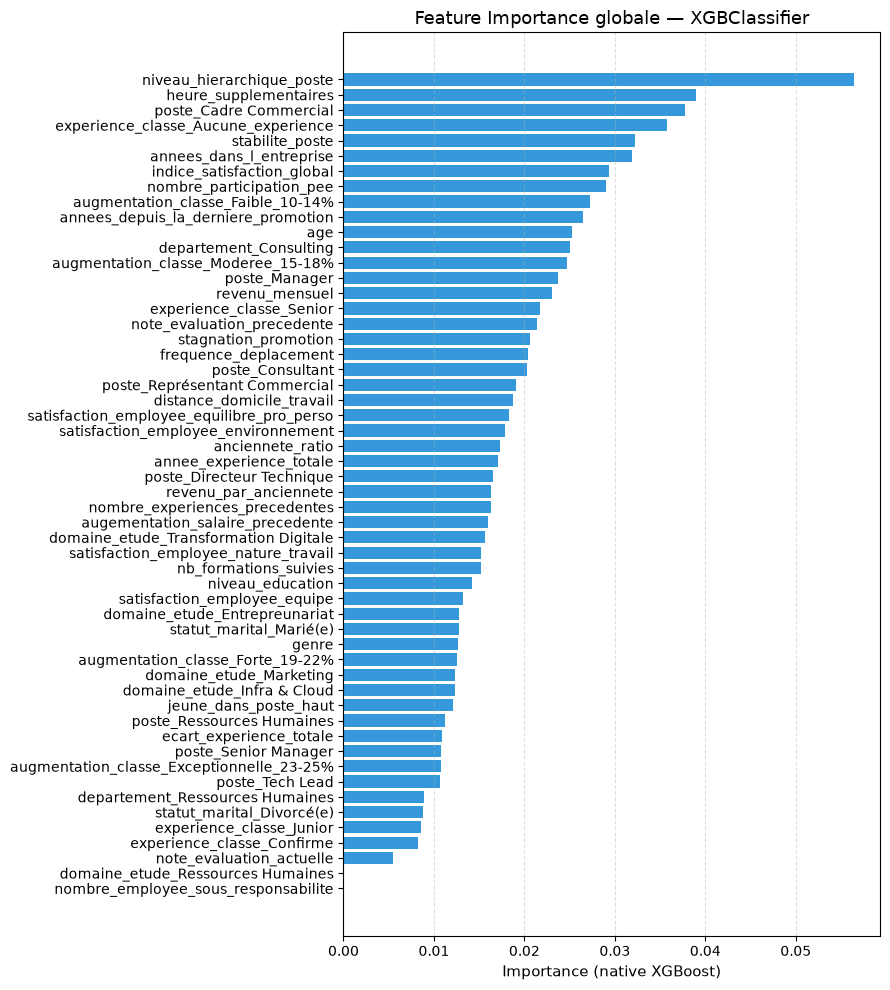

In [7]:
# Feature importance native du modèle optimisé
importances = xgb_model_v2.feature_importances_
feature_names = X2_train.columns

df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(df_importance['feature'], df_importance['importance'], color='#3498db')
ax.set_xlabel("Importance (native XGBoost)", fontsize=11)
ax.set_title("Feature Importance globale — XGBClassifier", fontsize=13)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Commentaires graphique :

- Il y a bien une distribution pareto entre l'importance relative de chaque var
- Le niveau hierarchique_du_poste a une importance maximal quasi le double de la deuxieme heure_supplementaire
- 

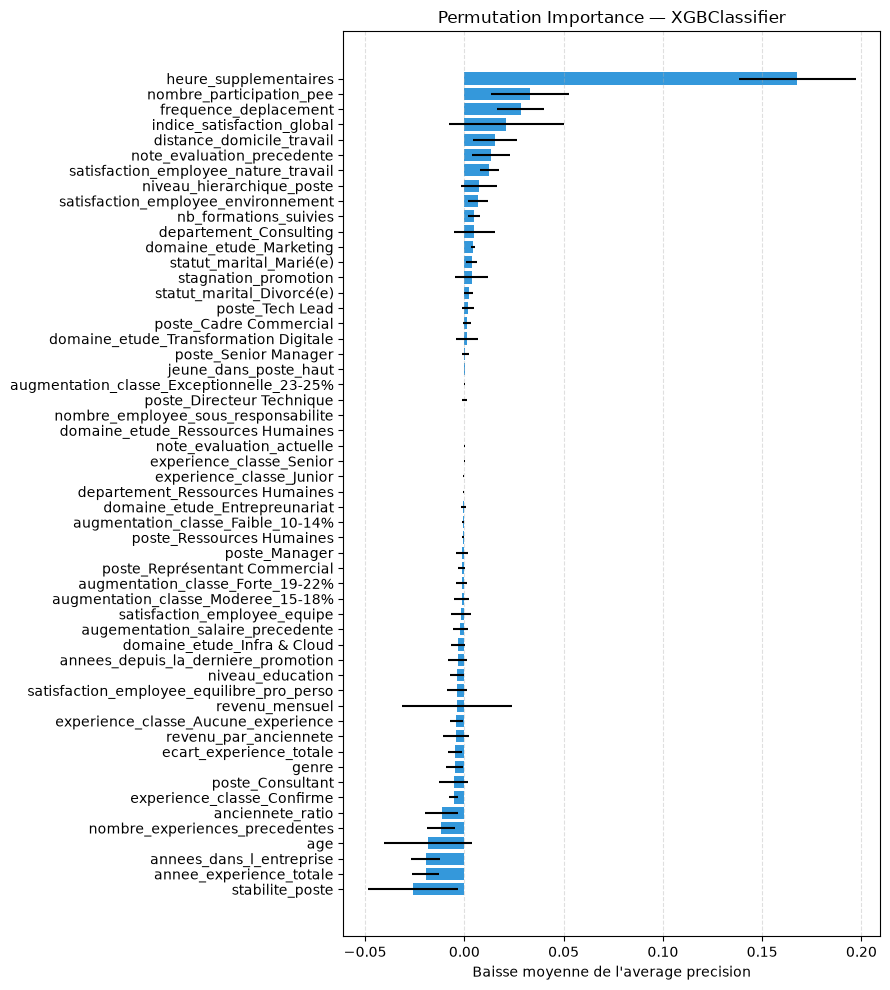

In [8]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    xgb_model_v2,
    X2_test,
    y2_test,
    n_repeats=30,
    random_state=42,
    scoring='average_precision',
    n_jobs=-1
)

importances = perm_result.importances_mean
std = perm_result.importances_std
feature_names = X2_test.columns
indices = np.argsort(importances)

plt.figure(figsize=(9, 10))
plt.title("Permutation Importance — XGBClassifier")
plt.barh(range(len(indices)), importances[indices], align="center", xerr=std[indices], color='#3498db')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Baisse moyenne de l'average precision")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Ce deuxieme graphique permet de mélanger aléatoirement une variable et on regarde de combien la performance chute.
Le XGBoost fonctionne sur du boosting séquentiel, chaque arbre corrige les erreurs du précédent. Permutation importance permet dans ce contexte de mesurer la notion d'incertitude sur l'importance native.

La barre d'erreur a pour sens statistique :
- si elle est grande, l'importance de la variable est instable/peu fiable
- Si elle est petite, l'effet est robuste

Ici il y a 4 grandes barres :

revenu_mensuel;stabilite_poste; qui évolue négativement et
indice_de_satisfaction_gloable et heures_supplementaires qui font évoluer l'average precision positivement

### Waterfall

création du TreeExplainer qui servira pour les deux graphiques Waterfall local ET Beeswarm global

In [9]:
import shap
from shap import TreeExplainer

explainer = shap.TreeExplainer(xgb_model_v2)
shap_values_test = explainer(X2_test)

c:\Projets\Projet4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Illustration de la feature importance locale 

Pour un modèle classification, Le SHAP va calculer non pas la différence entre la prédiction de la target et une valeur de référence, mais va calculer la différence entre la probabilité prédite et une probabilité de référence 

In [10]:
idx_classe_0 = np.where(y2_test.values == 0)[0][0]  # premier exemple "reste"
idx_classe_1 = np.where(y2_test.values == 1)[0][0]  # premier exemple "démissionne"


In [11]:
idx_classe_1

np.int64(4)

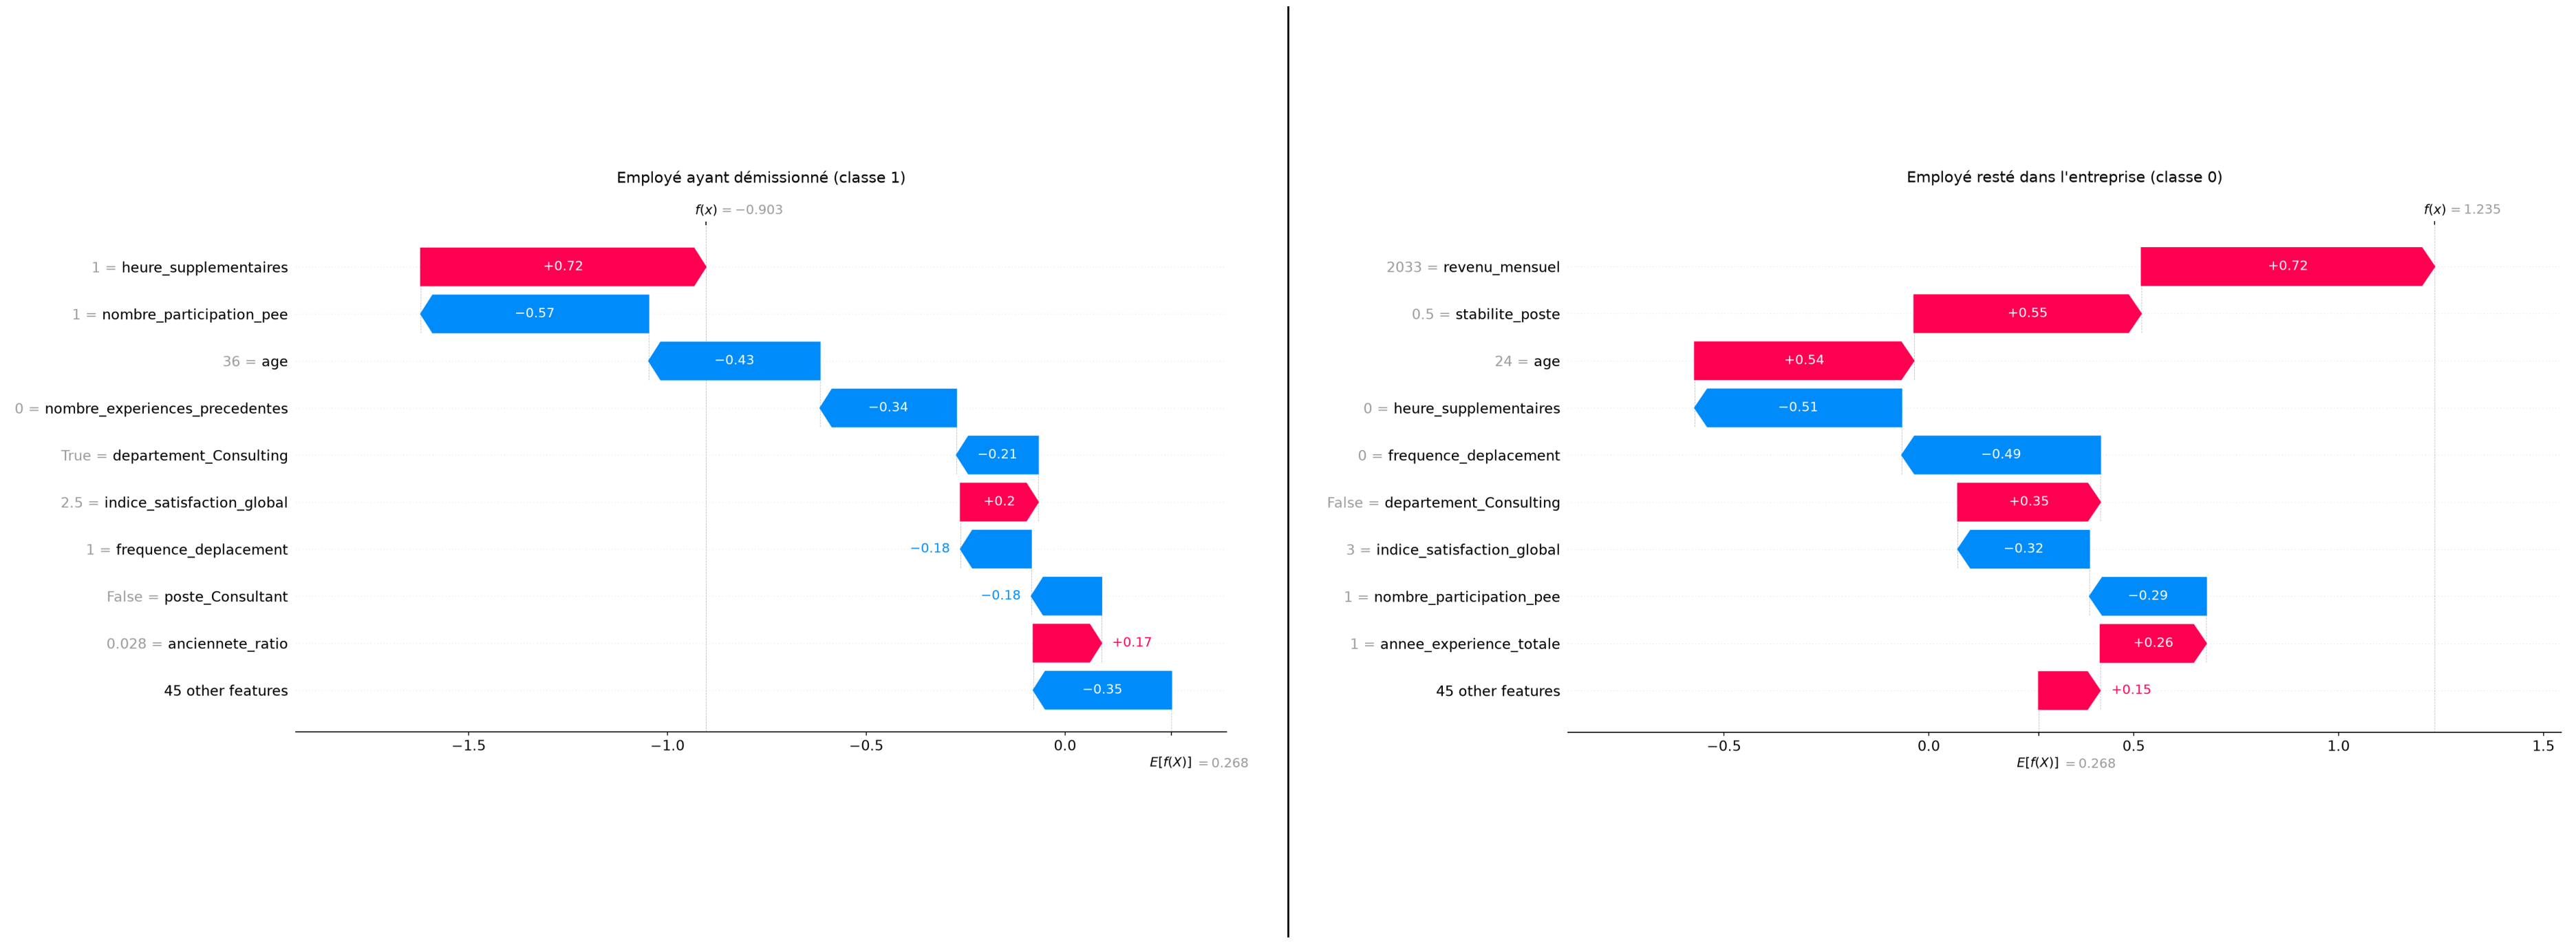

In [12]:
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.rcParams.update({'font.size': 10})

n_features = 10


# ============================================================
# 1. Waterfall — employé ayant démissionné
# ============================================================

shap.plots.waterfall(
    shap_values_test[idx_classe_1],
    max_display=n_features,
    show=False
)

fig_shap_1 = plt.gcf()
fig_shap_1.set_size_inches(16, 8)

plt.title(
    "Employé ayant démissionné (classe 1)",
    fontsize=14,
    pad=20
)

plt.tight_layout()

buffer_1 = BytesIO()
fig_shap_1.savefig(
    buffer_1,
    format="png",
    dpi=150,
    bbox_inches="tight"
)
plt.close(fig_shap_1)

buffer_1.seek(0)
image_1 = mpimg.imread(buffer_1)


# ============================================================
# 2. Waterfall — employé resté dans l'entreprise
# ============================================================

shap.plots.waterfall(
    shap_values_test[idx_classe_0],
    max_display=n_features,
    show=False
)

fig_shap_0 = plt.gcf()
fig_shap_0.set_size_inches(16, 8)

plt.title(
    "Employé resté dans l'entreprise (classe 0)",
    fontsize=14,
    pad=20
)

plt.tight_layout()

buffer_0 = BytesIO()
fig_shap_0.savefig(
    buffer_0,
    format="png",
    dpi=150,
    bbox_inches="tight"
)
plt.close(fig_shap_0)

buffer_0.seek(0)
image_0 = mpimg.imread(buffer_0)


# ============================================================
# 3. Réunion des deux graphiques dans un seul output
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(38, 15),
    gridspec_kw={'wspace': 0.05}
)

# Graphique de gauche
axes[0].imshow(image_1)
axes[0].axis("off")

# Graphique de droite
axes[1].imshow(image_0)
axes[1].axis("off")

# Ligne noire verticale de séparation
fig.add_artist(
    plt.Line2D(
        [0.5, 0.5],
        [0.05, 0.95],
        transform=fig.transFigure,
        color="black",
        linewidth=2
    )
)

plt.subplots_adjust(
    left=0.01,
    right=0.99,
    top=0.98,
    bottom=0.02
)

plt.show()


buffer_1.close()
buffer_0.close()

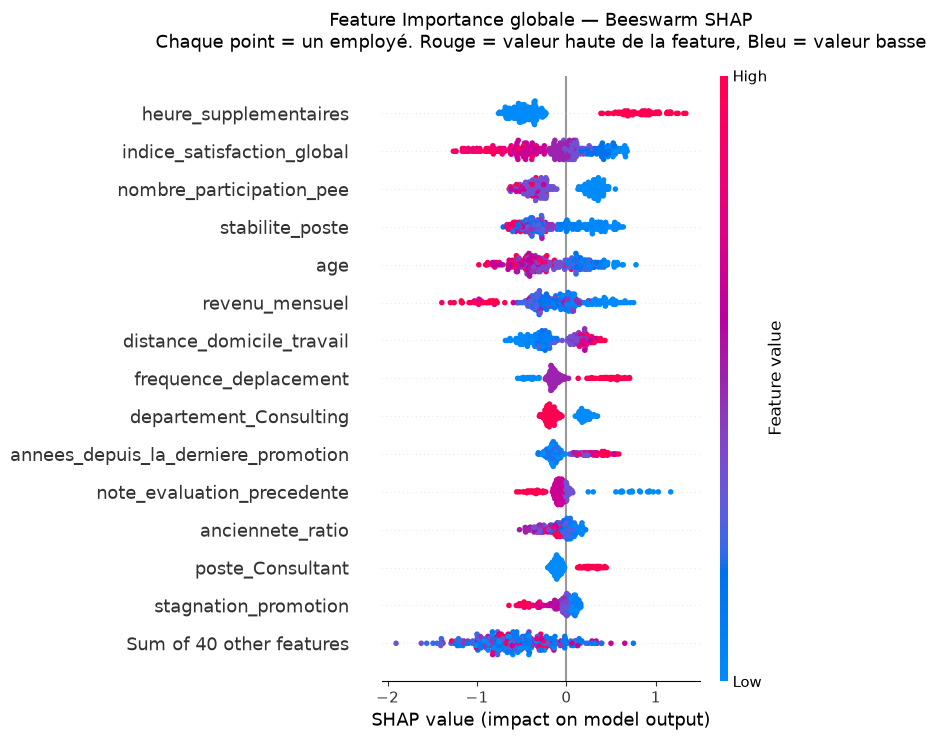

In [14]:
plt.figure(figsize=(12, 10))
shap.plots.beeswarm(shap_values_test, max_display=15, show=False)
plt.title(
    "Feature Importance globale — Beeswarm SHAP\n"
    "Chaque point = un employé. Rouge = valeur haute de la feature, Bleu = valeur basse",
    fontsize=13, pad=20
)
plt.tight_layout()
plt.show()

d
## Commentaires des résultats

### Permutation Importance (globale)

Le deuxième graphique Permutation Importance (Global) : prend le modèle déjà entraîné, puis mélange aléatoirement les valeurs d'une seule variable à la fois dans le jeu de test, et permet d'afficher de combien l'average precision du modèle se dégrade. Plus la baisse est forte, plus la variable était utile au modèle pour bien prédire.

**Ce qu'on observe :**
- `heure_supplementaires` domine très largement (~0.17 de baisse) et passe devant `niveau_hierarchique_poste` — c'est de loin la variable la plus critique pour la performance du modèle. Cette variable reste dans le top 3, ce qui confirme sa robustesse (existence d'une convergence entre les deux méthodes, signal positif).
- Un deuxième groupe modéré : `nombre_participation_pee`, `frequence_deplacement`, `indice_satisfaction_global`.
- Les barres noires (barre d'erreur).
- Ce deuxième graphique permet de mélanger aléatoirement une variable et on regarde de combien la performance chute.

Le XGBoost fonctionne sur du boosting séquentiel, chaque arbre corrige les erreurs du précédent. Permutation Importance permet dans ce contexte de mesurer la notion d'incertitude sur l'importance native.

**La barre d'erreur a pour sens statistique :**
- si elle est grande, l'importance de la variable est instable/peu fiable
- si elle est petite, l'effet est robuste

Ici il y a 4 grandes barres :
`revenu_mensuel`, `stabilite_poste`, qui évoluent négativement, et `indice_satisfaction_global` et `heure_supplementaires` qui font évoluer l'average precision positivement.

### Feature Importance native XGBoost (globale)

Ce premier graphique donne des propriétés internes du modèle, calculées pendant l'entraînement, à savoir le gain moyen apporté par chaque variable à chaque fois qu'elle est utilisée pour couper un arbre.

**Ce qu'on observe :**
- `niveau_hierarchique_poste` arrive en tête (il est invisible dans le Permutation Importance, deuxième graphique).
- Beaucoup de variables ont une importance non-nulle et "lissée".

Il nécessite de croiser les deux méthodes.

### Waterfalls, SHAP Local — deux employés

Ce graphique permet de changer complètement d'échelle. Ce n'est plus une tendance générale sur toute la population, mais celle d'un individu précis, et on décompose sa prédiction exacte.

**À gauche (démission) :**
- L'individu part d'une base moyenne de 0.268 et arrive à un score final de -0.903 (donc un risque de démission faible selon le modèle).
  - `heure_supplementaires = 1` pousse fortement vers le risque (+0.72)
  - Mais `nombre_participation_pee = 1`, `age = 36`, `nombre_experiences_precedentes = 0` tirent fortement vers la stabilité
  - Le cumul de ces facteurs négatifs l'emporte, expliquant pourquoi, malgré les heures sup, le modèle prédit un score bas (-0.9)

**À droite (resté) :**
- L'employé part du même score de base, mais arrive à un score élevé (1.235), c'est-à-dire un risque élevé de partir alors qu'il est resté (potentiellement un faux positif).
  - `revenu_mensuel = 2033` (bas) pousse fortement vers le risque (+0.72)
  - `stabilite_poste = 0.5` et `age = 24` (jeune) renforcent ce risque perçu
  - Seul `heure_supplementaires = 0` tire vers la stabilité, mais insuffisamment.

Beeswarm SHAP (global)

Chaque ligne = une variable, classée de la plus importante en jhaut à la moins importante, selon la moyenne des valeurs absolues des Shapley Balues.
Chque point = un employé du jeu de test.
Chaque point a une position horizontale et dit si cet employé voit son risque de démission augmenter (à droite Shap > 0) ou diminuer (à gauche Shap <0) à cause de cette variable précisément.
La couleur dit si, pour cet employé, la valeur de la variable est haute ou basse (bleu)

Ce qu'on observe :

- heure_supplementaires : nuage bleu compact à gauche, nuage rouge compact à droite → relation quasi binaire et sans ambiguïté : pas d'heures sup = protège, heures sup = pousse fortement vers la démission. C'est la variable la plus discriminante ET la plus lisible. Même chose pour pee et pour Departement_Consulting.
- satisfaction_gloable nuage très mélangé : pas d'effet net
- frequence deplacement : rouge à droite ; les déplacement fréquent pousse à la dé"mission. 



Différence avec Permutation Importance et Feature Importance donnent chacun un seul chiffre ar variables et disent "combien" une variable compte, mais "comment" ni "dans quel sens".

Le Beeswarm est un point entre le global et le local : c'est la juxtaposition de miliers de valeurs locales (une Shap Value par employé) de manière agrégée redonne une lecture globale. IL donne le sens de l'effet (la couleur) (démission ou stabilité), et la dispersion de l'effet (est ce que tous les employés réagissent pareil à cette variable ? de façon homogène (heure_supplémentaires) ou de façon hétérogène (comme indice_satisfaction_gloable)

| Graphique | Échelle | Question à laquelle il répond |
|---|---|---|
| Permutation Importance | Globale, sur données test | "Quelles variables sont vraiment indispensables pour que le modèle généralise bien ?" |
| Feature Importance native | Globale, sur données train | "Quelles variables le modèle a-t-il le plus utilisées pour construire ses arbres ?" |
| Beeswarm SHAP | Globale, sur données test (vue individu par individu) | "Quelles variables comptent le plus, dans quel sens (risque ↑ ou ↓) et avec quelle cohérence à travers tous les employés ?" |
| Waterfall (x2) | Locale, un individu | "Pour CET employé précis, quels facteurs ont fait pencher la balance ?" |

